In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("churn-ds.csv")

In [4]:
print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

First 5 rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies      

In [5]:
df.drop("customerID", axis=1, inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.dropna(inplace=True)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df = pd.get_dummies(df, drop_first=True)
print("\nProcessed Data Shape:", df.shape)



Processed Data Shape: (7032, 31)


In [6]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("\n Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


 Logistic Regression
Accuracy: 0.7874911158493249

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [10]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:\n", cm_lr)


Confusion Matrix:
 [[915 118]
 [181 193]]


In [11]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\n XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


 XGBoost
Accuracy: 0.7739872068230277

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:09:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [12]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:\n", cm_xgb)


Confusion Matrix:
 [[903 130]
 [188 186]]


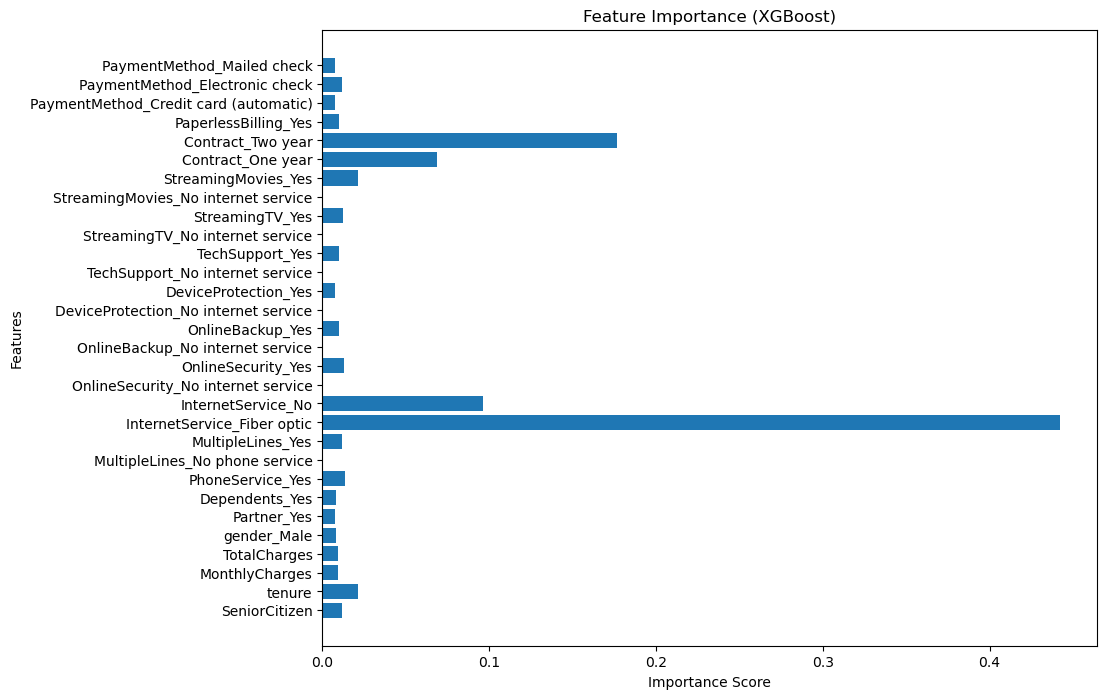

In [13]:
importance = xgb.feature_importances_
plt.figure(figsize=(10, 8))
plt.barh(X.columns, importance)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [14]:
lr_acc = accuracy_score(y_test, y_pred_lr)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print("\n FINAL COMPARISON")
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
if xgb_acc > lr_acc:
    print("👉 XGBoost performs better!")
else:
    print("👉 Logistic Regression performs better!")


 FINAL COMPARISON
Logistic Regression Accuracy: 0.7875
XGBoost Accuracy: 0.7740
👉 Logistic Regression performs better!
